**EDA: Химические соединения против вируса гриппа**

Данные содержат 1001 химическое соединение с молекулярными дескрипторами и тремя целевыми переменными:
- IC50, mM - концентрация, подавляющая активность вируса на 50%
- CC50, mM - концентрация, убивающая 50% клеток
- SI = CC50/IC50 - индекс селективности

**Импортируем библиотеки**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
import seaborn as sns

**Загружаем данные**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving project chemical data.xlsx to project chemical data.xlsx


In [26]:
df = pd.read_excel(list(uploaded.keys())[0], index_col=0)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,348.262234,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,126.946370,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,110.156000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,264.321000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,315.457000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,409.283000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,904.777000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


**Проверяем структуру и качество данных**

In [4]:
print('Типы данных')
print(df.dtypes.value_counts())

#проверяем пропуски
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
total_nans = df.isnull().sum().sum()
print(f'Всего пропущенных значений: {total_nans}')
print(f'Колонки с пропусками: {missing_cols.to_string()}')

Типы данных
float64    107
int64      106
Name: count, dtype: int64
Всего пропущенных значений: 36
Колонки с пропусками: MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3


           IC50, mM   CC50, mM          SI
count     1001.0000  1001.0000   1001.0000
mean       222.8052   589.1107     72.5088
std        402.1697   642.8675    684.4827
min          0.0035     0.7008      0.0115
25%         12.5154    99.9990      1.4333
50%         46.5852   411.0393      3.8462
75%        224.9759   894.0892     16.5667
max       4128.5294  4538.9762  15620.6000
skewness     3.6749     1.9733     18.0132
kurtosis    22.4503     5.6794    361.4167


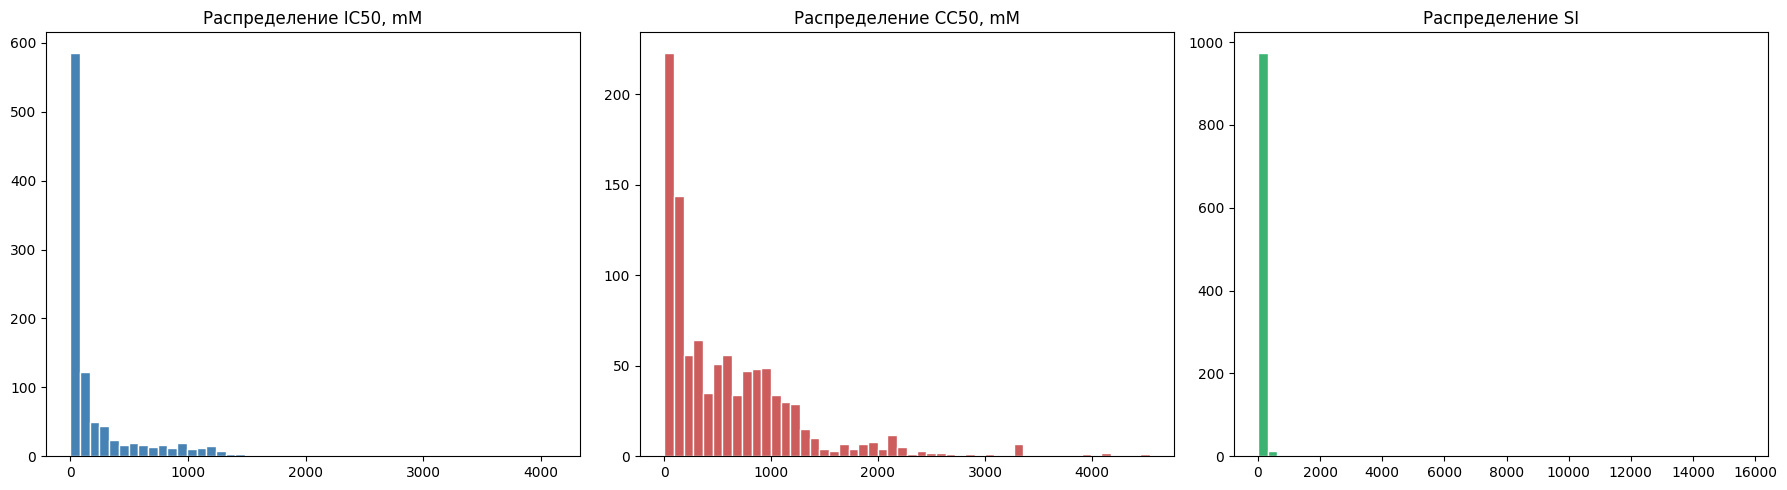

In [ ]:
#изучим статистику целевых переменных
targets = ['IC50, mM', 'CC50, mM', 'SI']
stats_df = df[targets].describe().round(4)
stats_df.loc['skewness'] = df[targets].skew().round(4)
stats_df.loc['kurtosis'] = df[targets].kurt().round(4)
print(stats_df.to_string())

#построим график распределения целевых
colors = ['steelblue', 'indianred', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

for ax, col, color in zip(axes, targets, colors):
    ax.hist(df[col].dropna(), bins = 50, color = color, edgecolor = 'white')
    ax.set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()

Вывод: на основе статистик иожем сделать вывод, что нужно логарифмировать все три переменные. В исходном виде данные непригодны для построения моделей: разница от минимального показателя от максимального превышает в миллионы раз, огромные выбросы, распределения далеки от нормального.

**Логарифмируем целевые переменные**

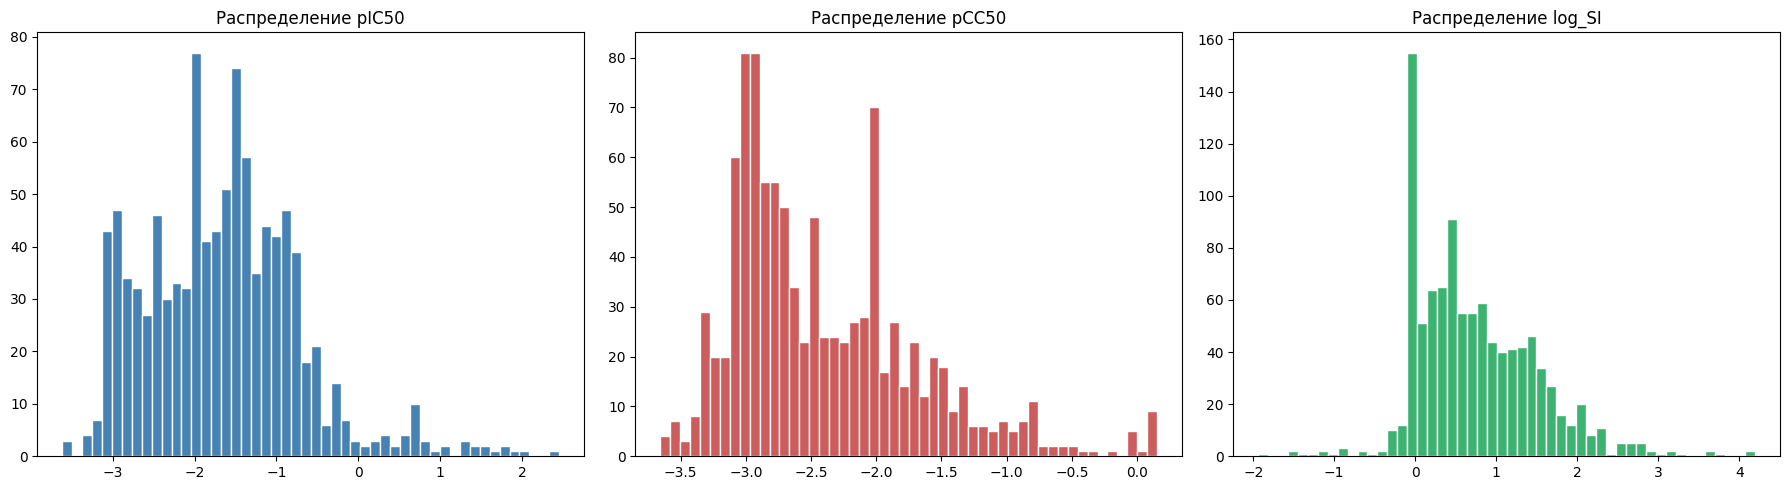

              pIC50      pCC50     log_SI
count     1001.0000  1001.0000  1001.0000
mean        -1.6637    -2.4067     0.7431
std          0.9408     0.7157     0.7536
min         -3.6158    -3.6570    -1.9397
25%         -2.3521    -2.9514     0.1563
50%         -1.6682    -2.6139     0.5850
75%         -1.0974    -2.0000     1.2192
max          2.4539     0.1544     4.1937
skewness     0.7391     1.0734     0.7965
kurtosis     1.1894     1.1151     1.4779


In [27]:
df['pIC50'] = -np.log10(df['IC50, mM'] + 1e-9)
df['pCC50'] = -np.log10(df['CC50, mM'] + 1e-9)
df['log_SI'] = np.log10(df['SI'] + 1e-9)

log_targets = ['pIC50', 'pCC50', 'log_SI']
colors = ['steelblue', 'indianred', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

for ax, col, color in zip(axes, log_targets, colors):
    ax.hist(df[col].dropna(), bins = 50, color = color, edgecolor = 'white')
    ax.set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()

stats_log_df = df[log_targets].describe().round(4)
stats_log_df.loc['skewness'] = df[log_targets].skew().round(4)
stats_log_df.loc['kurtosis'] = df[log_targets].kurt().round(4)
print(stats_log_df.to_string())

Вывод:  ассиметрия и эксцесс выровнялись. Переменные приблизились к нормальному распределению. В фармакологии принято вычислять отрицательный логарифм у IC50 и CC50. И записывается он как pIC50 и pCC50 от латинского potenz (мощность).

- IC50 -концентрация, подавляющая активность вируса на 50%. Чем меньше IC50, тем активнее соединение. При отрицательном логарифмировании шкала переворачивается: чем больше pIC50, тем активнее. Это удобнее - активность растет вместе с числом, как и в большинстве других метрик. После логарифмирования распределение pIC50 стало близким к нормальному, с умеренным правым хвостом и равномерным разбросом от -4 до 2. По сравнению с исходной IC50 распределение стало симметричным - большинство соединений показывают схожую активность.

- CC50 - концентрация, при которой погибает 50% клеток. Чем меньше CC50, тем токсичнее соединение. При логарифмировании с минусом шкала переорачивается: чем выше показатель, тем токсичнее препарат. Если pIC50 мы хотим максимизировать, то pCC50 - минимизировать. После логарифмирования pCC50 распределена в диапазоне от -3.5 до 0. Распределение умеренно скошено вправо, что говорит о том, что большинство соединений токсичны при малых концентрациях.

- единственная из трех переменных, где не берется отрицательный логарифм, SI. Большая асимметрия исходного SI после логарифмирования снизилась до приемлемого уровня. Пик графика около 0 с длинным правым хвостом до 4. Это означает, что большинство соединений имеют невысокую селективность, только единичные кандидаты достигают высоких значений (log_SI больше 2).

In [12]:
df['IC50_above_median'] = (df['IC50, mM'] > df['IC50, mM'].median()).astype(int)
df['CC50_above_median'] = (df['CC50, mM'] > df['CC50, mM'].median()).astype(int)
df['SI_above_median'] = (df['SI'] > df['SI'].median()).astype(int)
df['SI_above_8'] = (df['SI'] > 8).astype(int)
print('Баланс классов (SI > 8):')
proportions = df['SI_above_8'].value_counts(normalize = True) * 100
print(f'Класс 1 (SI > 8): {proportions[1]:.2f}%')
print(f'Класс 0 (SI < 8): {proportions[0]:.2f}%')

Баланс классов (SI > 8):
Класс 1 (SI > 8): 35.66%
Класс 0 (SI < 8): 64.34%


 Порог SI > 8 - это осмысленный химический порог: соединение в 8 раз безопаснее чем активно, что уже говорит о реальном потенциале как лекарственного кандидата. С учетом показателей почти 36% соединений потенциально может стать лекарственными

**Обрабатываем пропуски**


In [13]:
#выделяем признаки
target_cols = ['IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log_SI', 'IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8']
features_raw = df.drop(columns = target_cols).select_dtypes(include = [np.number])

#заполняем пропуски медианой
imputer = SimpleImputer(strategy = 'median')
features_imputed = imputer.fit_transform(features_raw)
features_raw = pd.DataFrame(features_imputed, columns = features_raw.columns, index = features_raw.index)

if features_raw.isnull().sum().sum() == 0:
    print('Пропуски успешно заполнены')

#удаляем константные признаки
selector = VarianceThreshold(threshold = 0.01)
selector.fit(features_raw)
features_var_names = features_raw.columns[selector.get_support()]
features_var = features_raw[features_var_names].copy()
nzv_removed = features_raw.shape[1] - features_var.shape[1]
print(f'Удалено константных признаков: {nzv_removed}')
print(f'Осталось признаков: {features_var.shape[1]}')

#ограничиваем выбросы молекулярных дескрипторов
def clip_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(lower = q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

features_cleaned = features_var.apply(clip_outliers)

Пропуски успешно заполнены
Удалено константных признаков: 34
Осталось признаков: 176


Вывод: заполнили пропуски медианой. Удалили константные признаки, так как они ничего не говорят о различиях между соединениями. Их наличие повлияло бы на качество модели, ее переобучение и скорость, также было бы сложно интерпретировать полученные данные.
Чтобы обрабоботать выбросы в молекулах использовали клиппинг. Он позволил  сохранить молекулу, приравняв аномальные дескрипторы  к максимально разумному значению

**Удаляем мультиколлинеарные признаки**

In [14]:
corr_matrix = features_cleaned.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]
features_decorr = features_cleaned.drop(columns = drop_corr)

print(f'Удалено мультиколлинеарных признаков (r > 0.9): {len(drop_corr)}')
print(f'Признаков после фильтрации: {features_decorr.shape[1]}')

Удалено мультиколлинеарных признаков (r > 0.9): 37
Признаков после фильтрации: 139



Вывод: выбран порог корреляции 0.9 - стандарт для молекулярных дескрипторов. 
При высокой мультиколлинеарности линейные модели нестабильны, коэффициенты неинтерпретируемы.

**Строим матрицу корреляций для отобранных признаков**

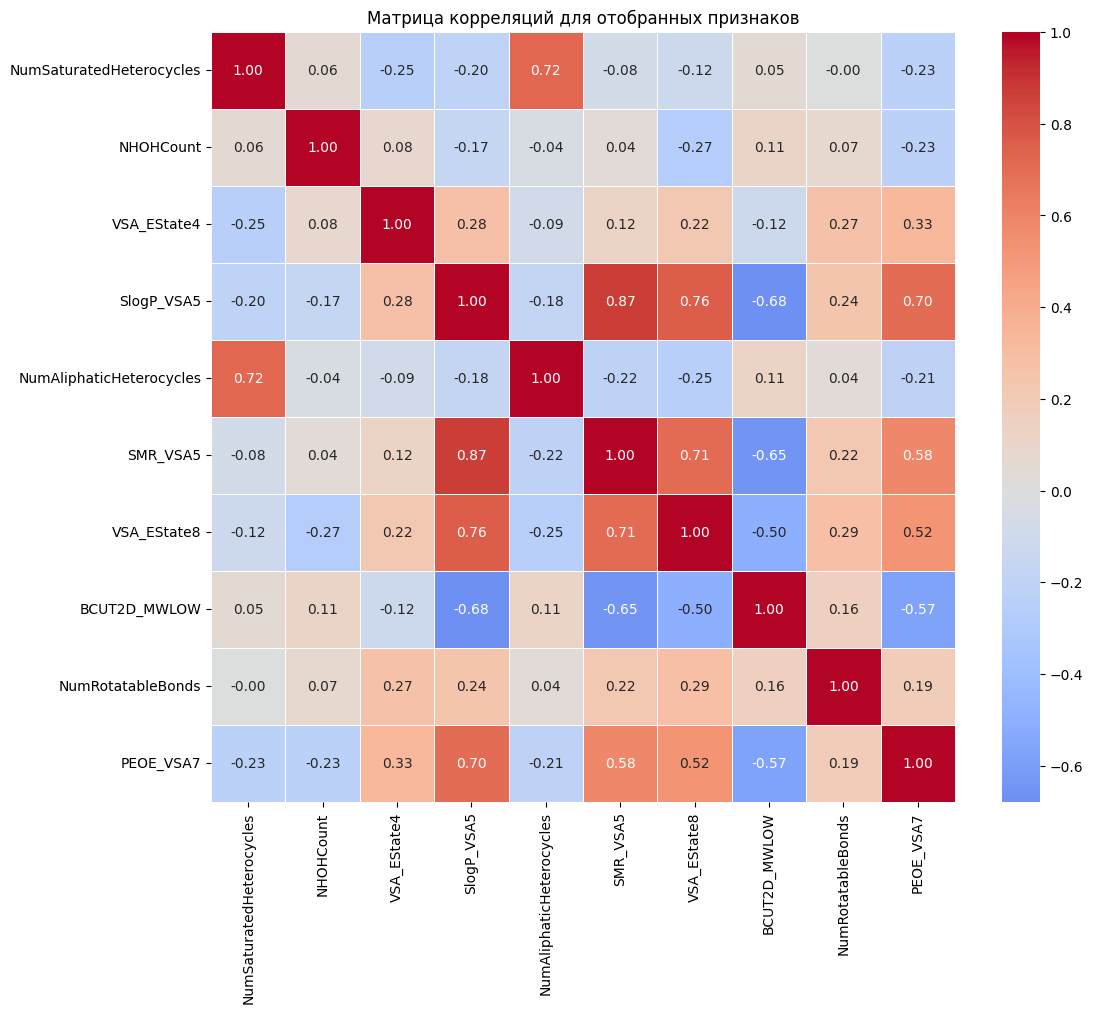

In [18]:
pIC50 = df['pIC50']

#отбираем числовые признаки
numeric_df = features_decorr.select_dtypes(include = [np.number])
non_constant_cols = numeric_df.columns[numeric_df.std() > 1e-6]
clean_numeric_df = numeric_df[non_constant_cols]

#выбираем 10 признаков с наибольшей корреляцией
top_features = clean_numeric_df.corrwith(pIC50).abs().sort_values(ascending = False).head(10).index
corr_subset = clean_numeric_df[top_features].corr()

#рисуем матрицу корреляций
plt.figure(figsize = (12, 10))
sns.heatmap(corr_subset, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0, linewidths = 0.7)
plt.title('Матрица корреляций для отобранных признаков')
plt.show()

**Сохраняем очищенный датасет**

In [20]:
df_final = pd.concat([features_decorr.reset_index(drop=True),
                       df[target_cols].reset_index(drop=True)], axis=1)

df_final.to_csv('chemical_data.csv', index = False)

print('Сохранено: chemical_data.csv')
print(f'Итоговая размерность: {df_final.shape}')
print(f'Признаков: {features_decorr.shape[1]}')

Сохранено: chemical_data.csv
Итоговая размерность: (1001, 149)
Признаков: 139


In [21]:
from google.colab import files
files.download('chemical_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>